In [2]:
import os
print(os.getcwd())

c:\Users\Sameer\Downloads\mutual_fund_analytics\notebooks


In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [4]:
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/02_nav_history_cleaned.csv'

In [5]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
c:\Users\Sameer\Downloads\mutual_fund_analytics\notebooks


In [6]:
import os

print(os.getcwd())

print(os.path.exists("data/processed/02_nav_history_cleaned.csv"))
print(os.path.exists("../data/processed/02_nav_history_cleaned.csv"))
print(os.path.exists("../../data/processed/02_nav_history_cleaned.csv"))

c:\Users\Sameer\Downloads\mutual_fund_analytics\notebooks
False
True
False


In [7]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [9]:
import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

# Date conversion
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# VaR and CVaR calculation
results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 50:
        continue

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    results.append([
        amfi_code,
        round(var_95, 6),
        round(cvar_95, 6)
    ])

var_cvar = pd.DataFrame(
    results,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

var_cvar.to_csv(
    "../reports/advanced_analytics/var_cvar_report.csv",
    index=False
)

print(var_cvar.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


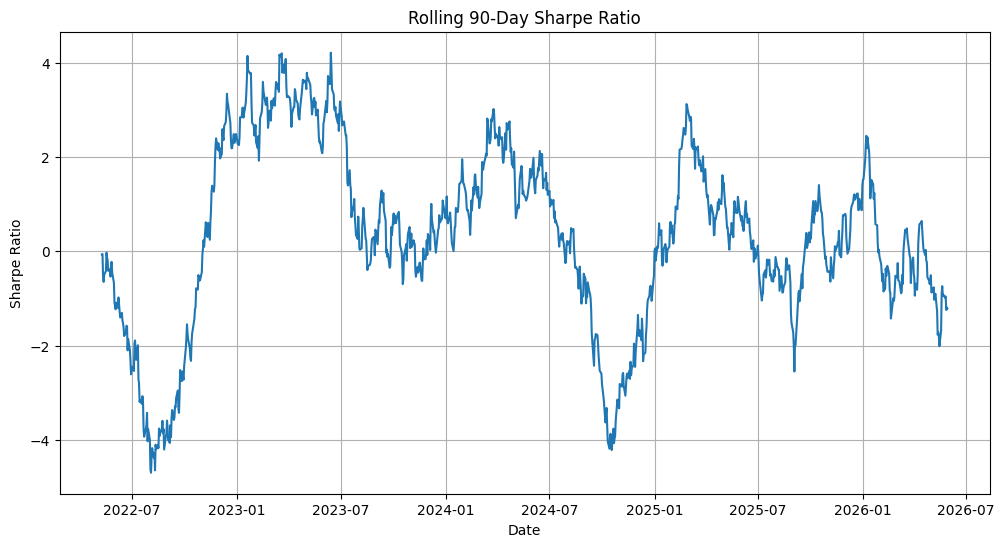

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Choose one fund
fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]].copy()

# Daily returns
fund["return"] = fund["nav"].pct_change()

# Rolling Sharpe Ratio (90 days)
rolling_mean = fund["return"].rolling(90).mean()
rolling_std = fund["return"].rolling(90).std()

fund["rolling_sharpe"] = (
    rolling_mean / rolling_std
) * np.sqrt(252)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    fund["date"],
    fund["rolling_sharpe"]
)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig(
    "../reports/advanced_analytics/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
import pandas as pd

# Load transactions
df = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

# Convert date
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# First transaction month
df["cohort_month"] = (
    df.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.to_period("M")
)

# Transaction month
df["transaction_month"] = (
    df["transaction_date"]
    .dt.to_period("M")
)

# Cohort table
cohort = (
    df.groupby(["cohort_month", "transaction_month"])
    ["investor_id"]
    .nunique()
    .reset_index()
)

# Save
cohort.to_csv(
    "../reports/advanced_analytics/cohort_analysis.csv",
    index=False
)

print(cohort.head())

  cohort_month transaction_month  investor_id
0      2024-01           2024-01         1577
1      2024-01           2024-02          540
2      2024-01           2024-03          567
3      2024-01           2024-04          541
4      2024-01           2024-05          550


In [12]:
import pandas as pd

# Load transactions
df = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

# Keep only SIP transactions
sip = df[
    df["transaction_type"].str.lower() == "sip"
].copy()

# Count SIP transactions per investor
sip_continuity = (
    sip.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

# Categorize continuity
sip_continuity["continuity_status"] = sip_continuity[
    "sip_count"
].apply(
    lambda x: "Active" if x >= 3 else "Inactive"
)

# Save report
sip_continuity.to_csv(
    "../reports/advanced_analytics/sip_continuity.csv",
    index=False
)

print(sip_continuity.head())

  investor_id  sip_count continuity_status
0   INV000001          2          Inactive
1   INV000002          3            Active
2   INV000003          2          Inactive
3   INV000004          6            Active
4   INV000005          3            Active


In [13]:
import pandas as pd

df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(df.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [14]:
import pandas as pd

# Load holdings
df = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

# HHI calculation
hhi = (
    df.groupby("sector")["weight_pct"]
    .apply(
        lambda x: (x / x.sum() * 100)
        .pow(2)
        .sum()
    )
    .reset_index(name="HHI")
)

hhi.to_csv(
    "../reports/advanced_analytics/sector_hhi.csv",
    index=False
)

print(hhi.head())

           sector          HHI
0      Automobile   405.626690
1         Banking   215.110905
2          Cement  1032.601241
3  Consumer Goods  1216.194512
4     Diversified   973.619981


In [15]:
import pandas as pd

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

hhi = (
    portfolio.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index()
)

hhi.columns = ["amfi_code", "HHI"]

hhi["risk_level"] = hhi["HHI"].apply(
    lambda x: "High Concentration" if x > 0.15 else "Diversified"
)

hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print(hhi.head())

   amfi_code       HHI          risk_level
0     100016  0.139534         Diversified
1     100033  0.147592         Diversified
2     101206  0.129332         Diversified
3     101207  0.200700  High Concentration
4     102885  0.174709  High Concentration
